In [2]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [3]:
%pip install -q -U transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 113.8 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 114.0 MB/s eta 0:00:00


In [1]:
!ls -lh /content

total 110M
-rw-r--r-- 1 root root 4.2M Aug 27 09:42 현두지갑_01.jpg
-rw-r--r-- 1 root root 2.8M Aug 27 09:41 민준지갑_01.jpg
-rw-r--r-- 1 root root 3.3M Aug 27 09:42 성현지갑_01.jpg
-rw-r--r-- 1 root root 4.0M Aug 27 09:41 병주지갑_01.jpg
-rw-r--r-- 1 root root 3.5M Aug 27 09:42 성현지갑_02.jpg
-rw-r--r-- 1 root root 3.2M Aug 27 09:41 민준지갑_02.jpg
-rw-r--r-- 1 root root 4.1M Aug 27 09:42 현두지갑_02.jpg
-rw-r--r-- 1 root root 4.3M Aug 27 09:41 병주지갑_02.jpg
-rw-r--r-- 1 root root 4.0M Aug 27 09:42 병주지갑_03.jpg
-rw-r--r-- 1 root root 4.3M Aug 27 09:42 성현지갑_03.jpg
-rw-r--r-- 1 root root 3.8M Aug 27 09:41 민준지갑_03.jpg
-rw-r--r-- 1 root root 4.1M Aug 27 09:42 현두지갑_03.jpg
-rw-r--r-- 1 root root 4.6M Aug 27 09:42 성현지갑_04.jpg
-rw-r--r-- 1 root root 3.2M Aug 27 09:41 민준지갑_04.jpg
-rw-r--r-- 1 root root 4.5M Aug 27 09:42 병주지갑_04.jpg
-rw-r--r-- 1 root root 4.2M Aug 27 09:42 현두지갑_04.jpg
-rw-r--r-- 1 root root 2.9M Aug 27 09:41 민준지갑_05.jpg
-rw-r--r-- 1 root root 4.3M Aug 27 09:42 성현지갑_05.jpg
-rw-r--r-- 1 root root 3.5M Aug 27 

In [4]:
import glob
import os

all_jpg_files = glob.glob("/content/*.jpg")

original_files = sorted([
    path
    for path in all_jpg_files
    if not os.path.basename(path).startswith("crop_")
    and "지갑_" in os.path.basename(path)
])

crop_files = sorted([
    path
    for path in all_jpg_files
    if os.path.basename(path).startswith("crop_")
    and "지갑_" in os.path.basename(path)
])

print("Original:", len(original_files))
print("Crop:", len(crop_files))

Original: 19
Crop: 19


In [5]:
original_names = [
    os.path.basename(path)
    for path in original_files
]

crop_names = [
    os.path.basename(path).replace("crop_", "", 1)
    for path in crop_files
]

print("Original/Crop Pair 일치:", original_names == crop_names)

if original_names != crop_names:
    print("\n불일치 파일 확인:")

    for original, crop in zip(
        original_names,
        crop_names
    ):
        if original != crop:
            print(
                "Original:",
                original,
                "| Crop:",
                crop
            )

Original/Crop Pair 일치: True


In [6]:
from PIL import Image

original_images = [
    Image.open(path).convert("RGB")
    for path in original_files
]

crop_images = [
    Image.open(path).convert("RGB")
    for path in crop_files
]

print(
    "Original:",
    len(original_images)
)

print(
    "Crop:",
    len(crop_images)
)

Original: 19
Crop: 19


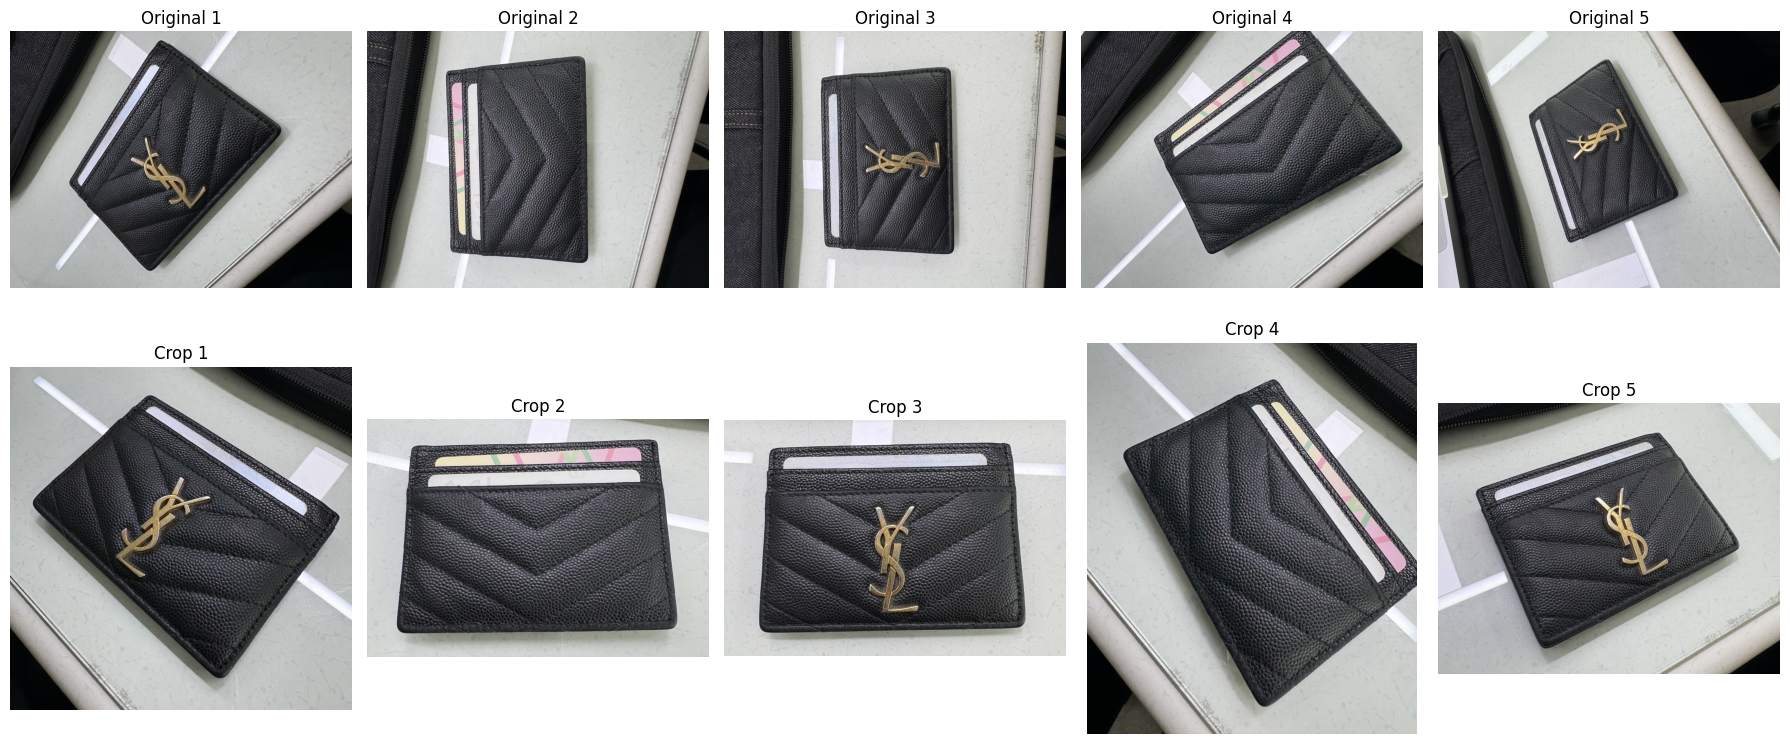

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2,
    5,
    figsize=(18, 8)
)

# 우선 처음 5장만 확인
for i in range(5):

    axes[0, i].imshow(
        original_images[i]
    )

    axes[0, i].set_title(
        f"Original {i+1}"
    )

    axes[0, i].axis("off")


    axes[1, i].imshow(
        crop_images[i]
    )

    axes[1, i].set_title(
        f"Crop {i+1}"
    )

    axes[1, i].axis("off")


plt.tight_layout()
plt.show()

In [8]:
labels = [
    os.path.splitext(
        os.path.basename(path)
    )[0]
    for path in original_files
]

for i, label in enumerate(labels):
    print(i, label)

0 민준지갑_01
1 민준지갑_02
2 민준지갑_03
3 민준지갑_04
4 민준지갑_05
5 병주지갑_01
6 병주지갑_02
7 병주지갑_03
8 병주지갑_04
9 병주지갑_05
10 성현지갑_01
11 성현지갑_02
12 성현지갑_03
13 성현지갑_04
14 성현지갑_05
15 현두지갑_01
16 현두지갑_02
17 현두지갑_03
18 현두지갑_04


In [9]:
def get_owner(label):
    return label.split("지갑_")[0]

In [10]:
import torch.nn.functional as F
from transformers import AutoModel, AutoProcessor

siglip_model_id = (
    "google/siglip2-base-patch16-224"
)

siglip_processor = (
    AutoProcessor.from_pretrained(
        siglip_model_id
    )
)

siglip_model = (
    AutoModel.from_pretrained(
        siglip_model_id,
        torch_dtype=torch.float16
    )
    .to(device)
)

siglip_model.eval()

print("SigLIP2 loaded!")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


preprocessor_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/253 [00:00<?, ?B/s]

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


tokenizer_config.json:   0%|          | 0.00/47.2k [00:00<?, ?B/s]

...

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.50GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

SigLIP2 loaded!


In [11]:
def get_siglip_embedding(image):

    inputs = siglip_processor(
        images=image,
        return_tensors="pt"
    )

    inputs = {
        k: (
            v.to(
                device,
                dtype=torch.float16
            )
            if v.is_floating_point()
            else v.to(device)
        )
        for k, v in inputs.items()
    }

    with torch.no_grad():

        outputs = (
            siglip_model
            .get_image_features(
                **inputs
            )
        )

    embedding = outputs.pooler_output

    embedding = F.normalize(
        embedding,
        p=2,
        dim=-1
    )

    return embedding

In [12]:
siglip_original_embeddings = torch.cat(
    [
        get_siglip_embedding(image)
        for image in original_images
    ],
    dim=0
)

print(
    "Original:",
    siglip_original_embeddings.shape
)

Original: torch.Size([19, 768])


In [13]:
siglip_crop_embeddings = torch.cat(
    [
        get_siglip_embedding(image)
        for image in crop_images
    ],
    dim=0
)

print(
    "Crop:",
    siglip_crop_embeddings.shape
)

Crop: torch.Size([19, 768])


In [14]:
from transformers import (
    AutoImageProcessor,
    AutoModel
)

dino_model_id = "facebook/dinov2-base"

dino_processor = (
    AutoImageProcessor.from_pretrained(
        dino_model_id
    )
)

dino_model = (
    AutoModel.from_pretrained(
        dino_model_id
    )
    .to(device)
)

dino_model.eval()

print("DINOv2 loaded!")

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

DINOv2 loaded!


In [15]:
def get_dino_embedding(image):

    inputs = dino_processor(
        images=image,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    with torch.no_grad():

        outputs = dino_model(
            **inputs
        )

    embedding = outputs.pooler_output

    embedding = F.normalize(
        embedding,
        p=2,
        dim=-1
    )

    return embedding

In [16]:
dino_original_embeddings = torch.cat(
    [
        get_dino_embedding(image)
        for image in original_images
    ],
    dim=0
)

print(
    "Original:",
    dino_original_embeddings.shape
)

Original: torch.Size([19, 768])


In [17]:
dino_crop_embeddings = torch.cat(
    [
        get_dino_embedding(image)
        for image in crop_images
    ],
    dim=0
)

print(
    "Crop:",
    dino_crop_embeddings.shape
)

Crop: torch.Size([19, 768])


In [18]:
def rank_candidates(
    query_index,
    embeddings,
    labels
):

    query_embedding = embeddings[
        query_index:query_index + 1
    ]

    query_owner = get_owner(
        labels[query_index]
    )

    results = []

    for i in range(len(labels)):

        if i == query_index:
            continue

        score = F.cosine_similarity(
            query_embedding,
            embeddings[i:i+1]
        ).item()

        results.append({
            "index": i,
            "label": labels[i],
            "owner": get_owner(labels[i]),
            "score": score,
            "correct":
                get_owner(labels[i])
                == query_owner
        })

    results.sort(
        key=lambda x: x["score"],
        reverse=True
    )

    return results

In [19]:
def top1_accuracy(
    embeddings,
    labels
):

    correct = 0

    for i in range(len(labels)):

        results = rank_candidates(
            i,
            embeddings,
            labels
        )

        if results[0]["correct"]:
            correct += 1

    return correct / len(labels)

In [20]:
print("===== Top-1 Accuracy =====")

print(
    "SigLIP Original:",
    round(
        top1_accuracy(
            siglip_original_embeddings,
            labels
        ),
        4
    )
)

print(
    "SigLIP Crop    :",
    round(
        top1_accuracy(
            siglip_crop_embeddings,
            labels
        ),
        4
    )
)

print(
    "DINO Original :",
    round(
        top1_accuracy(
            dino_original_embeddings,
            labels
        ),
        4
    )
)

print(
    "DINO Crop     :",
    round(
        top1_accuracy(
            dino_crop_embeddings,
            labels
        ),
        4
    )
)

===== Top-1 Accuracy =====
SigLIP Original: 0.9474
SigLIP Crop    : 0.9474
DINO Original : 1.0
DINO Crop     : 1.0


In [21]:
def recall_at_k(
    query_index,
    embeddings,
    labels,
    k
):

    query_owner = get_owner(
        labels[query_index]
    )

    results = rank_candidates(
        query_index,
        embeddings,
        labels
    )

    total_positive = sum(
        1
        for i, label in enumerate(labels)
        if (
            i != query_index
            and get_owner(label)
            == query_owner
        )
    )

    top_k = results[:k]

    retrieved_positive = sum(
        1
        for result in top_k
        if result["correct"]
    )

    return (
        retrieved_positive
        / total_positive
    )

In [22]:
import numpy as np

def mean_recall_at_k(
    embeddings,
    labels,
    k
):

    recalls = []

    for i in range(len(labels)):

        recall = recall_at_k(
            i,
            embeddings,
            labels,
            k
        )

        recalls.append(recall)

    return np.mean(recalls)

In [23]:
print("===== Mean Recall =====")

for k in [3, 5]:

    print(f"\nRecall@{k}")

    print(
        "SigLIP Original:",
        round(
            mean_recall_at_k(
                siglip_original_embeddings,
                labels,
                k
            ),
            4
        )
    )

    print(
        "SigLIP Crop    :",
        round(
            mean_recall_at_k(
                siglip_crop_embeddings,
                labels,
                k
            ),
            4
        )
    )

    print(
        "DINO Original :",
        round(
            mean_recall_at_k(
                dino_original_embeddings,
                labels,
                k
            ),
            4
        )
    )

    print(
        "DINO Crop     :",
        round(
            mean_recall_at_k(
                dino_crop_embeddings,
                labels,
                k
            ),
            4
        )
    )

===== Mean Recall =====

Recall@3
SigLIP Original: 0.7632
SigLIP Crop    : 0.7763
DINO Original : 0.7237
DINO Crop     : 0.7018

Recall@5
SigLIP Original: 0.9079
SigLIP Crop    : 0.9605
DINO Original : 0.9167
DINO Crop     : 0.9167


In [24]:
query_index = labels.index(
    "성현지갑_03"
)

In [25]:
sig_orig = rank_candidates(
    query_index,
    siglip_original_embeddings,
    labels
)

In [26]:
sig_crop = rank_candidates(
    query_index,
    siglip_crop_embeddings,
    labels
)

In [27]:
print(
    "===== 성현지갑_03 / SigLIP2 ====="
)

print("\n[Original]")

for rank, result in enumerate(
    sig_orig[:5],
    start=1
):

    mark = (
        "✅"
        if result["correct"]
        else "❌"
    )

    print(
        rank,
        result["label"],
        f"{result['score']:.4f}",
        mark
    )


print("\n[Crop]")

for rank, result in enumerate(
    sig_crop[:5],
    start=1
):

    mark = (
        "✅"
        if result["correct"]
        else "❌"
    )

    print(
        rank,
        result["label"],
        f"{result['score']:.4f}",
        mark
    )

===== 성현지갑_03 / SigLIP2 =====

[Original]
1 현두지갑_01 0.8467 ❌
2 현두지갑_03 0.8452 ❌
3 현두지갑_04 0.8398 ❌
4 병주지갑_05 0.8120 ❌
5 현두지갑_02 0.8115 ❌

[Crop]
1 민준지갑_02 0.8442 ❌
2 성현지갑_04 0.8413 ✅
3 병주지갑_02 0.8394 ❌
4 성현지갑_02 0.8389 ✅
5 민준지갑_04 0.8345 ❌


In [28]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": [
        "SigLIP2 Original",
        "SigLIP2 Crop",
        "DINOv2 Original",
        "DINOv2 Crop"
    ],

    "Top1_Accuracy": [
        top1_accuracy(
            siglip_original_embeddings,
            labels
        ),

        top1_accuracy(
            siglip_crop_embeddings,
            labels
        ),

        top1_accuracy(
            dino_original_embeddings,
            labels
        ),

        top1_accuracy(
            dino_crop_embeddings,
            labels
        )
    ],

    "Recall@3": [
        mean_recall_at_k(
            siglip_original_embeddings,
            labels,
            3
        ),

        mean_recall_at_k(
            siglip_crop_embeddings,
            labels,
            3
        ),

        mean_recall_at_k(
            dino_original_embeddings,
            labels,
            3
        ),

        mean_recall_at_k(
            dino_crop_embeddings,
            labels,
            3
        )
    ],

    "Recall@5": [
        mean_recall_at_k(
            siglip_original_embeddings,
            labels,
            5
        ),

        mean_recall_at_k(
            siglip_crop_embeddings,
            labels,
            5
        ),

        mean_recall_at_k(
            dino_original_embeddings,
            labels,
            5
        ),

        mean_recall_at_k(
            dino_crop_embeddings,
            labels,
            5
        )
    ]
})

display(
    comparison_df.round(4)
)

,Model,Top1_Accuracy,Recall@3,Recall@5
0,SigLIP2 Original,0.9474,0.7632,0.9079
1,SigLIP2 Crop,0.9474,0.7763,0.9605
2,DINOv2 Original,1.0000,0.7237,0.9167
3,DINOv2 Crop,1.0000,0.7018,0.9167
